In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

import matplotlib.pyplot as plt
import numpy as np

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


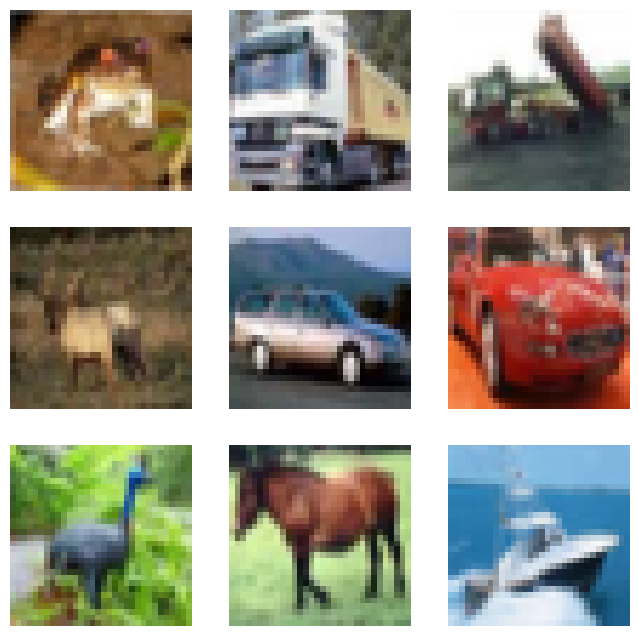

In [ ]:
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.axis("off")

plt.show()

In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
model = models.Sequential([

    layers.Conv2D(32,(3,3),activation='relu',
                  input_shape=(32,32,3)),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64,activation='relu'),

    layers.Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

In [ ]:
history = model.fit(
x_train,
y_train,
epochs=10,
validation_data=(x_test,y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 46ms/step - accuracy: 0.4519 - loss: 1.5233 - val_accuracy: 0.5519 - val_loss: 1.2603
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 45ms/step - accuracy: 0.5858 - loss: 1.1787 - val_accuracy: 0.6268 - val_loss: 1.0764
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 44ms/step - accuracy: 0.6376 - loss: 1.0390 - val_accuracy: 0.6545 - val_loss: 0.9951
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 43ms/step - accuracy: 0.6686 - loss: 0.9522 - val_accuracy: 0.6672 - val_loss: 0.9748
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 43ms/step - accuracy: 0.6923 - loss: 0.8881 - val_accuracy: 0.6592 - val_loss: 0.9993
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 43ms/step - accuracy: 0.7086 - loss: 0.8375 - val_accuracy: 0.6849 - val_loss: 0.9283
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.7247 - loss: 0.7932 - val_accuracy: 0.6818 - val_loss: 0.9266
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 43ms/step - accuracy: 0.7379 -

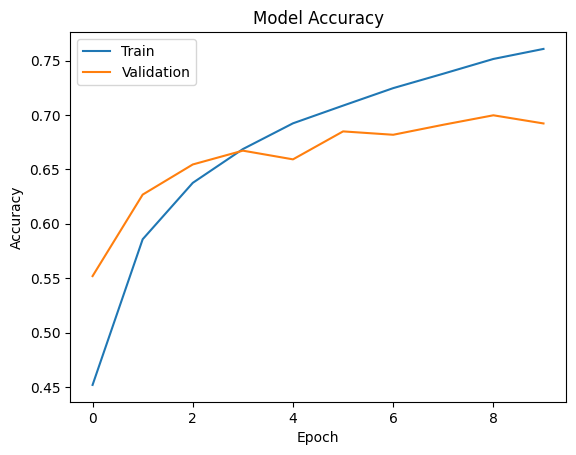

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(
x_test,
y_test
)

print("Test Accuracy:",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6922 - loss: 0.9127
Test Accuracy: 0.6922000050544739


In [ ]:
predictions = model.predict(x_test)

print(
np.argmax(predictions[0])
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
3


In [ ]:
model.save("cifar10_model.keras")